# 03 - Dashboard e Insights Avanzados

**Autor:** Julian Barbieri  
**Objetivo:** Visualizaciones avanzadas y generación de insights de negocio

---

## Cargar datos procesados

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import src.config as config
from data_processing import DataProcessor
from analysis import DataAnalyzer

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.figsize'] = (14, 8)

# Procesar datos
processor = DataProcessor(str(config.INPUT_FILE), encoding=config.ENCODING)
tablas = processor.procesar_todo()

# Análisis
analyzer = DataAnalyzer(tablas)
kpis = analyzer.ejecutar_analisis_completo()

print("✅ Datos cargados")

INFO:data_processing:============================================================
INFO:data_processing:INICIANDO PROCESAMIENTO DE DATOS
INFO:data_processing:============================================================
INFO:data_processing:Cargando datos desde c:\Users\julia\Data Science\ProyectoM3_JulianBarbieri\notebooks\data\processed\ventasTransformed.csv
INFO:data_processing:Datos cargados: 30000 filas, 33 columnas
INFO:data_processing:Creando tabla: Ciudades
INFO:data_processing:  ✓ 4 ciudades
INFO:data_processing:Creando tabla: Sucursales
INFO:data_processing:  ✓ 6 sucursales
INFO:data_processing:Creando tabla: Productos
INFO:data_processing:  ✓ 40 productos únicos
INFO:data_processing:Creando tabla: Clientes
INFO:data_processing:  ✓ 17507 clientes únicos
INFO:data_processing:Creando tabla: Vendedores
INFO:data_processing:  ✓ 30 vendedores
INFO:data_processing:Creando tabla: Facturas
INFO:data_processing:  ✓ 30000 facturas
INFO:data_processing:Creando tabla: DetalleFacturas
INFO:

✅ Datos cargados


## 📊 Dashboard 1: Visión General

### Métricas Clave

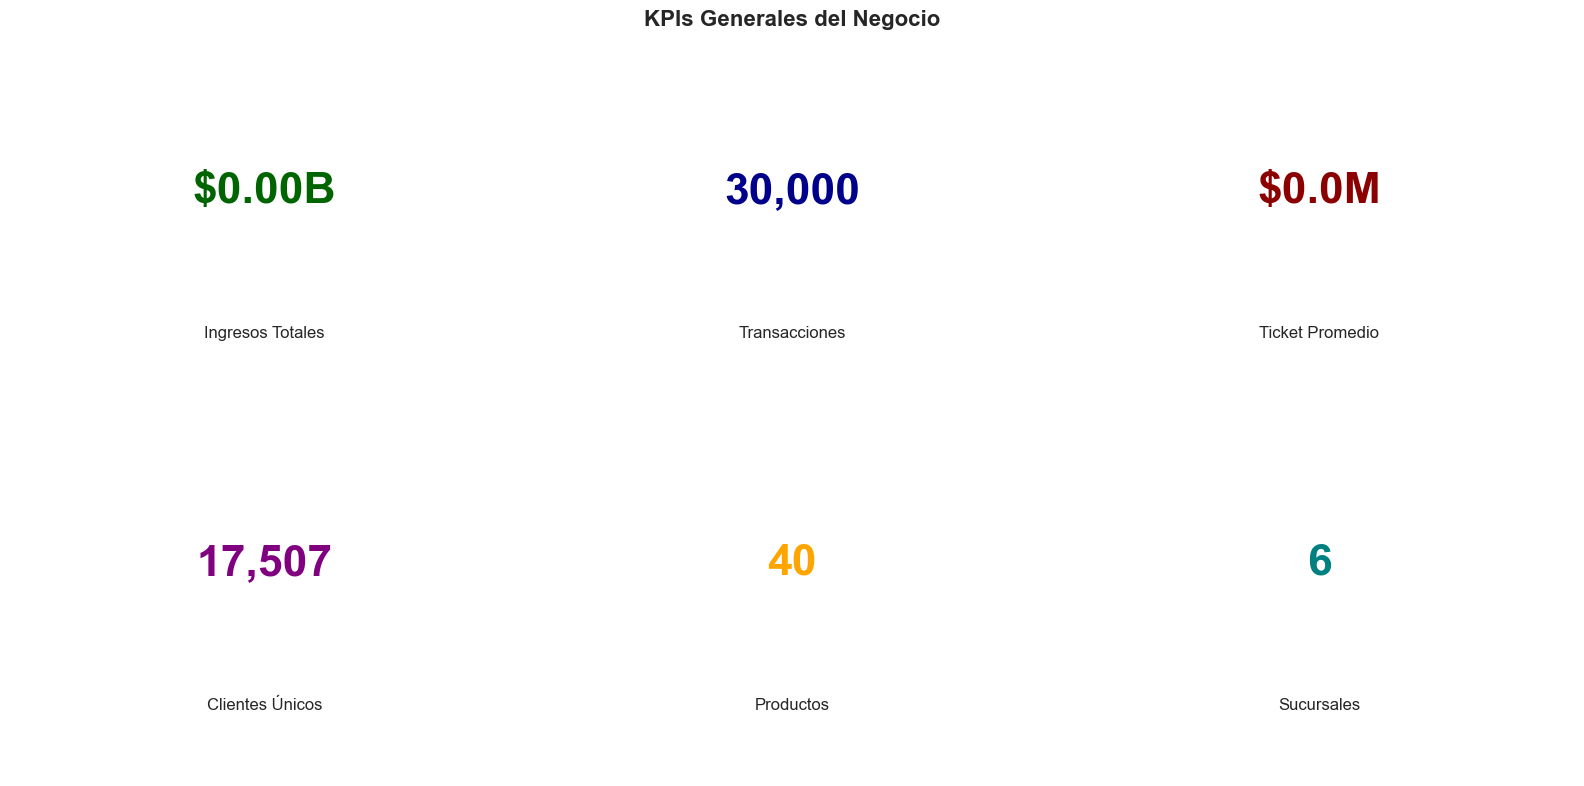

In [2]:
kpis_gen = kpis['generales']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('KPIs Generales del Negocio', fontsize=16, fontweight='bold')

# Total Ingresos
ax = axes[0, 0]
ax.text(0.5, 0.6, f"${kpis_gen['total_ingresos']/1e9:.2f}B", 
        ha='center', va='center', fontsize=32, fontweight='bold', color='darkgreen')
ax.text(0.5, 0.2, 'Ingresos Totales', ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Transacciones
ax = axes[0, 1]
ax.text(0.5, 0.6, f"{kpis_gen['numero_transacciones']:,}", 
        ha='center', va='center', fontsize=32, fontweight='bold', color='darkblue')
ax.text(0.5, 0.2, 'Transacciones', ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Ticket Promedio
ax = axes[0, 2]
ax.text(0.5, 0.6, f"${kpis_gen['ticket_promedio']/1e6:.1f}M", 
        ha='center', va='center', fontsize=32, fontweight='bold', color='darkred')
ax.text(0.5, 0.2, 'Ticket Promedio', ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Clientes
ax = axes[1, 0]
ax.text(0.5, 0.6, f"{kpis_gen['numero_clientes_unicos']:,}", 
        ha='center', va='center', fontsize=32, fontweight='bold', color='purple')
ax.text(0.5, 0.2, 'Clientes Únicos', ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Productos
ax = axes[1, 1]
ax.text(0.5, 0.6, f"{kpis_gen['numero_productos']}", 
        ha='center', va='center', fontsize=32, fontweight='bold', color='orange')
ax.text(0.5, 0.2, 'Productos', ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Sucursales
ax = axes[1, 2]
ax.text(0.5, 0.6, f"{kpis_gen['numero_sucursales']}", 
        ha='center', va='center', fontsize=32, fontweight='bold', color='teal')
ax.text(0.5, 0.2, 'Sucursales', ha='center', va='center', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.tight_layout()
plt.show()

## 📈 Dashboard 2: Análisis por Marca

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ingresos por marca
data = kpis['por_marca'].head(10)
sns.barplot(data=data, x='MarcaProducto', y='ingresos_totales', palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Marcas por Ingresos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Marca')
axes[0].set_ylabel('Ingresos ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Participación de mercado
data_pie = kpis['por_marca'].head(8)
colors = sns.color_palette('Set2', len(data_pie))
axes[1].pie(data_pie['ingresos_totales'], labels=data_pie['MarcaProducto'], 
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('Participación de Mercado (Top 8)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

ValueError: cannot convert float NaN to integer

ValueError: need at least one array to concatenate

<Figure size 1600x600 with 2 Axes>

## 🏪 Dashboard 3: Desempeño de Sucursales

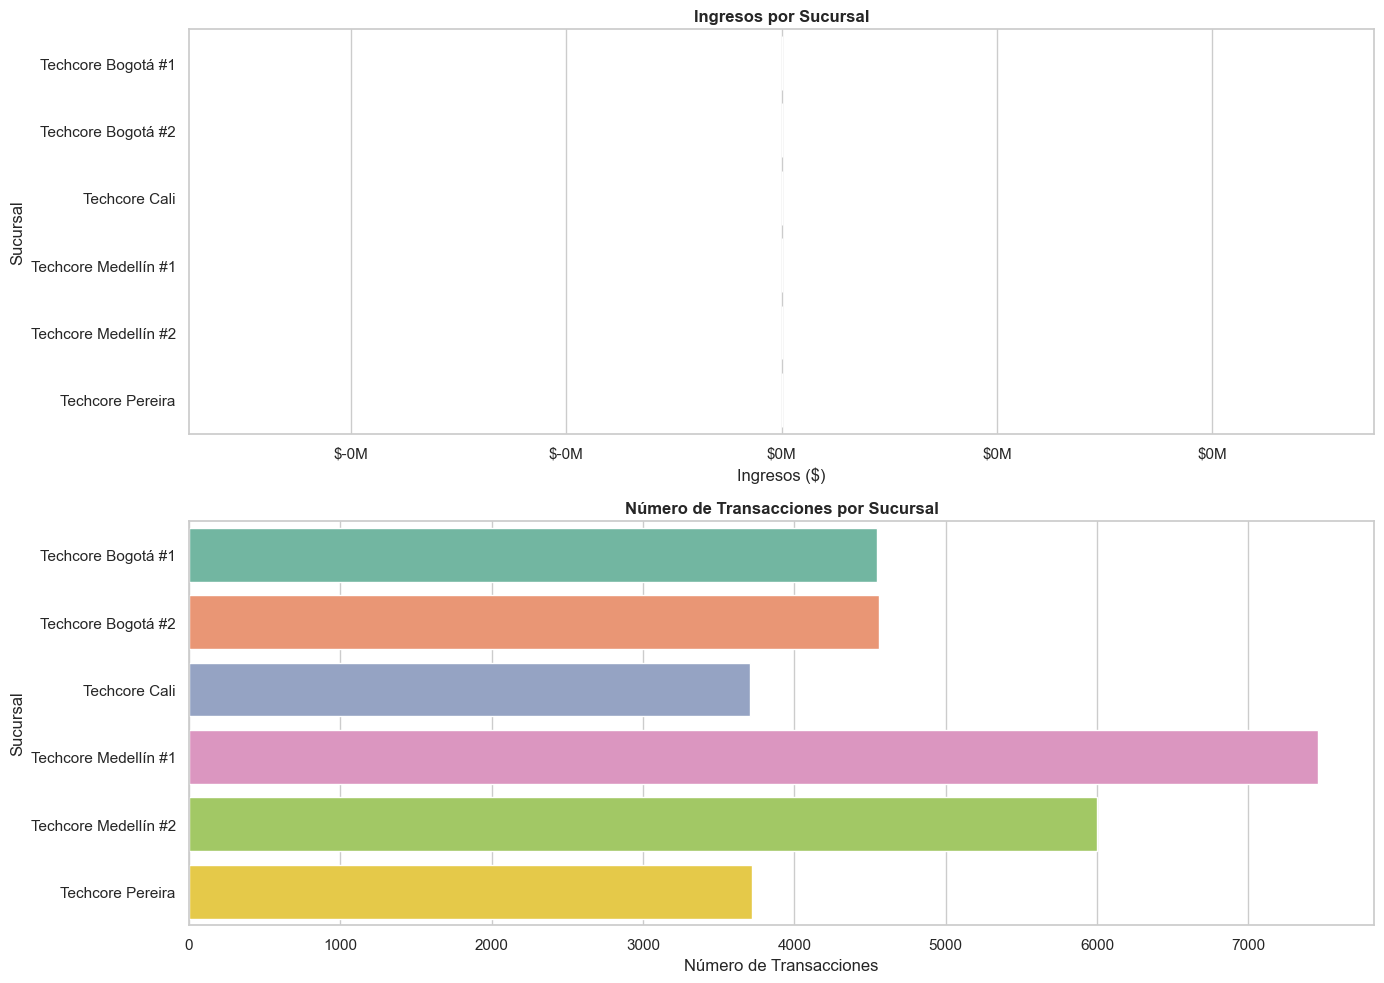

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

data = kpis['por_sucursal'].sort_values('ingresos_totales', ascending=False)

# Ingresos por sucursal
sns.barplot(data=data, y='SucursalNombre', x='ingresos_totales', palette='coolwarm', ax=axes[0])
axes[0].set_title('Ingresos por Sucursal', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ingresos ($)')
axes[0].set_ylabel('Sucursal')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Número de transacciones
sns.barplot(data=data, y='SucursalNombre', x='numero_transacciones', palette='Set2', ax=axes[1])
axes[1].set_title('Número de Transacciones por Sucursal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Número de Transacciones')
axes[1].set_ylabel('Sucursal')

plt.tight_layout()
plt.show()

## 👥 Dashboard 4: Análisis de Vendedores

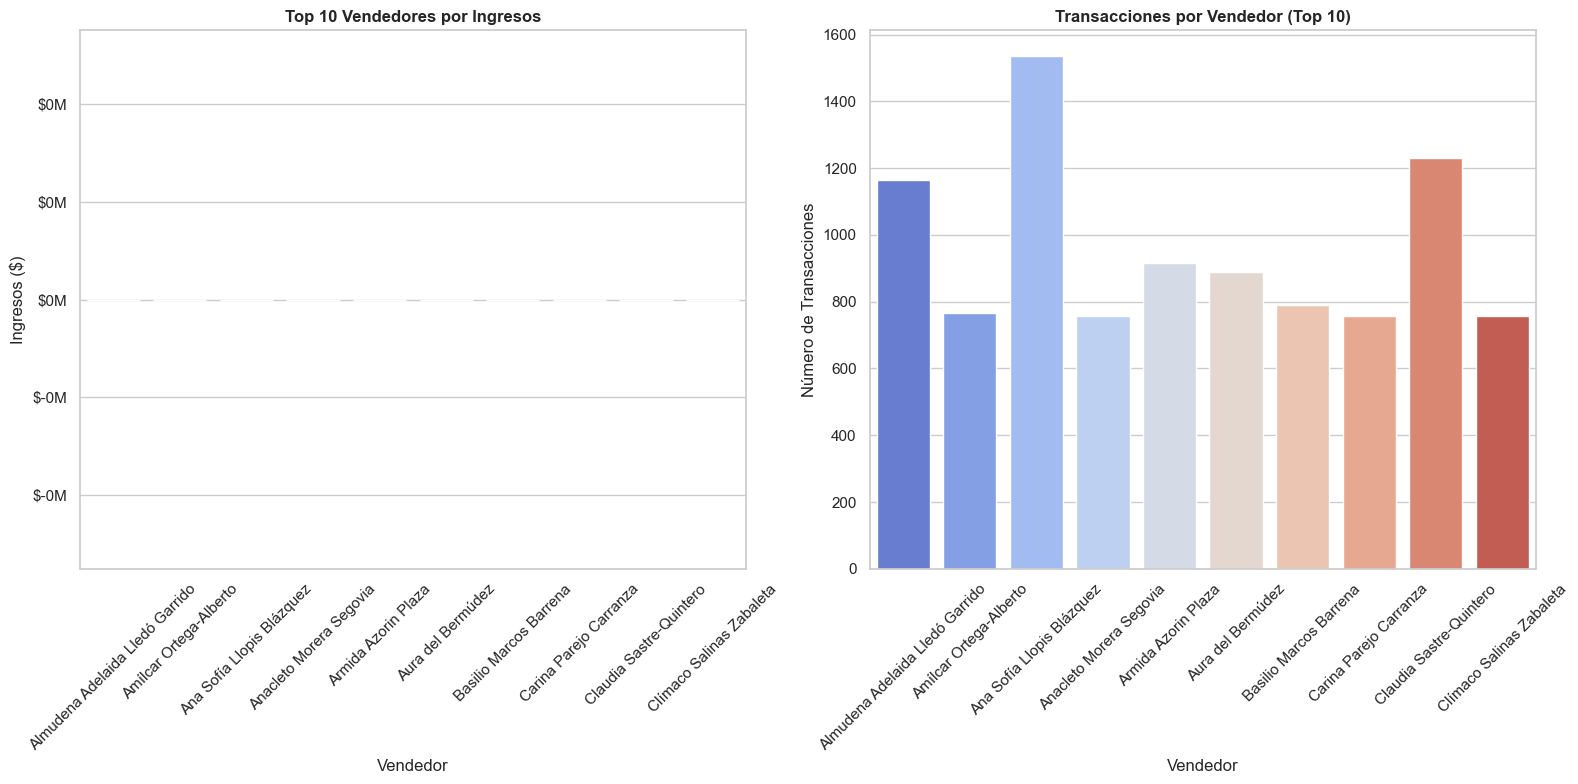

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

data = kpis['por_vendedor'].head(10)

# Ingresos por vendedor
sns.barplot(data=data, x='Vendedor', y='ingresos_totales', palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Vendedores por Ingresos', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Vendedor')
axes[0].set_ylabel('Ingresos ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Productividad (transacciones)
sns.barplot(data=data, x='Vendedor', y='numero_transacciones', palette='coolwarm', ax=axes[1])
axes[1].set_title('Transacciones por Vendedor (Top 10)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Vendedor')
axes[1].set_ylabel('Número de Transacciones')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 📅 Dashboard 5: Análisis Temporal

DateParseError: Unknown datetime string format, unable to parse: 2014-diciembre-01

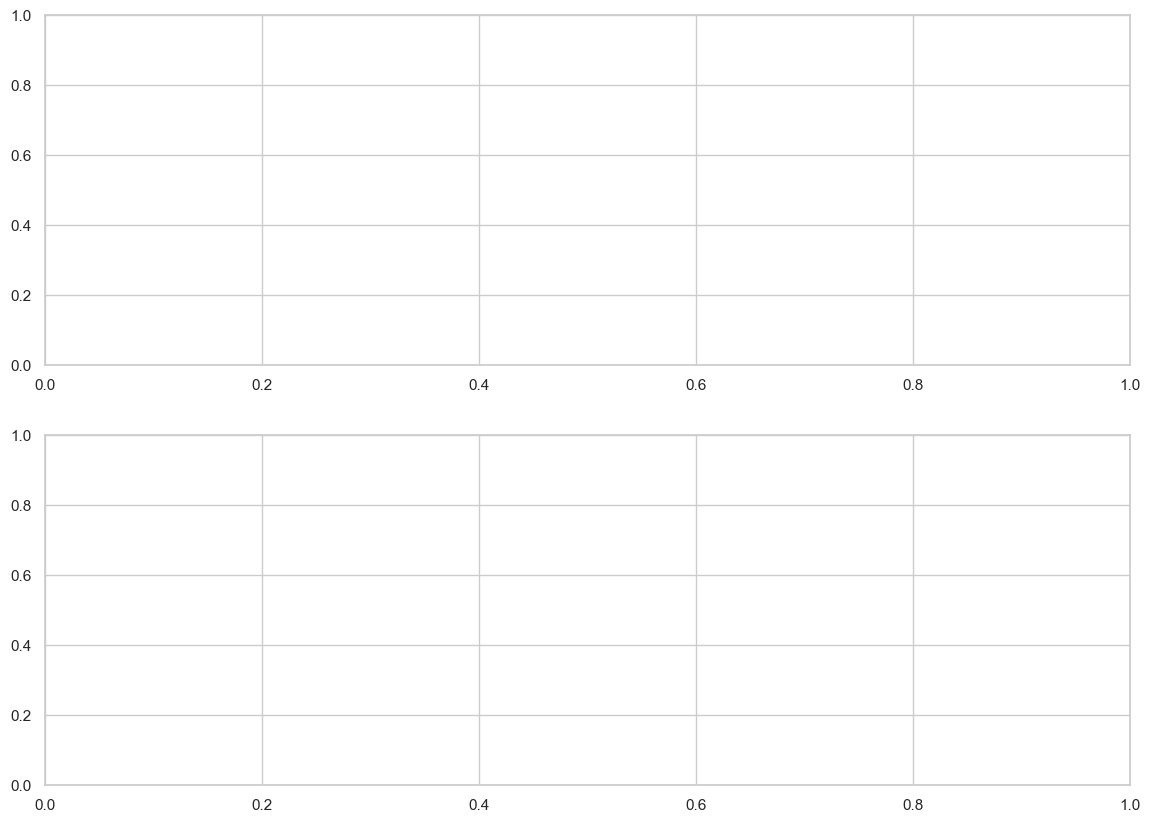

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

data = kpis['temporal'].copy()
data['fecha'] = pd.to_datetime(data['Anio'].astype(str) + '-' + data['Mes'].astype(str).str.zfill(2) + '-01')
data_sorted = data.sort_values('fecha')

# Ingresos temporal
axes[0].plot(data_sorted['fecha'], data_sorted['ingresos_totales'], marker='o', linewidth=2, 
             markersize=6, color='green')
axes[0].fill_between(data_sorted['fecha'], data_sorted['ingresos_totales'], alpha=0.3, color='green')
axes[0].set_title('Evolución de Ingresos Mensuales', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ingresos ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))
axes[0].grid(True, alpha=0.3)

# Transacciones temporal
axes[1].plot(data_sorted['fecha'], data_sorted['numero_transacciones'], marker='s', linewidth=2,
             markersize=6, color='blue')
axes[1].fill_between(data_sorted['fecha'], data_sorted['numero_transacciones'], alpha=0.3, color='blue')
axes[1].set_title('Evolución del Número de Transacciones', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Número de Transacciones')
axes[1].set_xlabel('Período')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 💳 Dashboard 6: Métodos de Pago

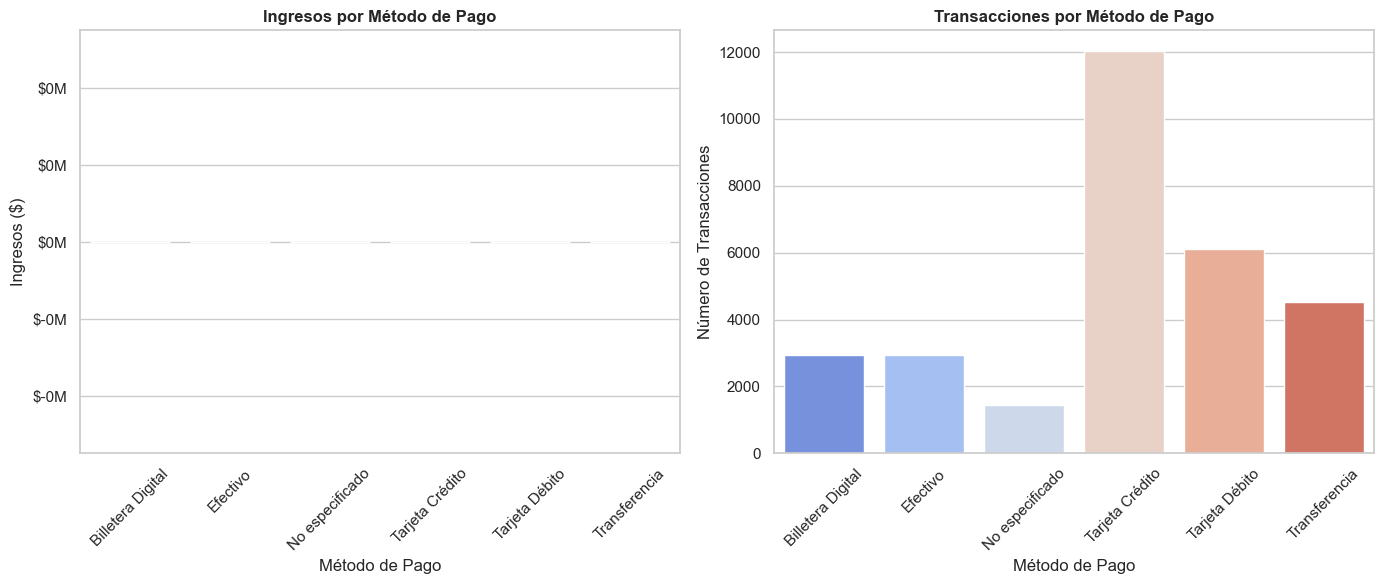

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data = kpis['por_metodo_pago'].sort_values('ingresos_totales', ascending=False)

# Ingresos
sns.barplot(data=data, x='MetodoPago', y='ingresos_totales', palette='Set2', ax=axes[0])
axes[0].set_title('Ingresos por Método de Pago', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Método de Pago')
axes[0].set_ylabel('Ingresos ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Transacciones
sns.barplot(data=data, x='MetodoPago', y='numero_transacciones', palette='coolwarm', ax=axes[1])
axes[1].set_title('Transacciones por Método de Pago', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Método de Pago')
axes[1].set_ylabel('Número de Transacciones')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 🎯 Insights y Recomendaciones

In [8]:
insights = f"""
╔════════════════════════════════════════════════════════════════════╗
║                    INSIGHTS PRINCIPALES                           ║
╚════════════════════════════════════════════════════════════════════╝

📊 DESEMPEÑO GENERAL:
  • Ingresos Totales: ${kpis['generales']['total_ingresos']:,.0f}
  • Transacciones: {kpis['generales']['numero_transacciones']:,}
  • Ticket Promedio: ${kpis['generales']['ticket_promedio']:,.0f}

🏆 MARCA LÍDER:
  • {kpis['por_marca'].iloc[0]['MarcaProducto']}
  • Ingresos: ${kpis['por_marca'].iloc[0]['ingresos_totales']:,.0f}
  • Participación: {kpis['por_marca'].iloc[0]['participacion_mercado_%']:.1f}%

⭐ PRODUCTO TOP:
  • {kpis['por_producto'].iloc[0]['NombreProducto']}
  • Ingresos: ${kpis['por_producto'].iloc[0]['ingresos_totales']:,.0f}

🏪 SUCURSAL LÍDER:
  • {kpis['por_sucursal'].iloc[0]['SucursalNombre']}
  • Ingresos: ${kpis['por_sucursal'].iloc[0]['ingresos_totales']:,.0f}
  • Transacciones: {kpis['por_sucursal'].iloc[0]['numero_transacciones']:.0f}

👤 VENDEDOR TOP:
  • {kpis['por_vendedor'].iloc[0]['Vendedor']}
  • Ingresos: ${kpis['por_vendedor'].iloc[0]['ingresos_totales']:,.0f}

💳 MÉTODO DE PAGO PREFERIDO:
  • {kpis['por_metodo_pago'].iloc[0]['MetodoPago']}
  • Transacciones: {kpis['por_metodo_pago'].iloc[0]['numero_transacciones']:.0f}
  • {kpis['por_metodo_pago'].iloc[0]['participacion_%']:.1f}% del total

╔════════════════════════════════════════════════════════════════════╗
║                    RECOMENDACIONES ESTRATÉGICAS                   ║
╚════════════════════════════════════════════════════════════════════╝

1. 🎯 ENFOQUE EN MARCAS:
   → Incrementar promociones en marcas no líderes para diversificar cartera
   → Mantener alianzas estratégicas con marcas de alto desempeño

2. 📈 OPTIMIZACIÓN DE SUCURSALES:
   → Análizar factores de éxito de sucursal líder
   → Implementar mejores prácticas en sucursales de bajo desempeño

3. 💼 GESTIÓN DE VENDEDORES:
   → Diseñar programas de capacitación basados en best practices
   → Establecer metas de ventas diferenciales por sucursal

4. 💳 MÉTODOS DE PAGO:
   → Promocionar métodos digitales para agilizar procesos
   → Analizar costos de transacción vs. ingresos por método

5. 👥 CLIENTES:
   → Crear programas de fidelización para clientes VIP
   → Implementar estrategias de retención para segmento de riesgo
"""

print(insights)


╔════════════════════════════════════════════════════════════════════╗
║                    INSIGHTS PRINCIPALES                           ║
╚════════════════════════════════════════════════════════════════════╝

📊 DESEMPEÑO GENERAL:
  • Ingresos Totales: $0
  • Transacciones: 30,000
  • Ticket Promedio: $0

🏆 MARCA LÍDER:
  • Acer
  • Ingresos: $0
  • Participación: nan%

⭐ PRODUCTO TOP:
  • Acer Aspire 5
  • Ingresos: $0

🏪 SUCURSAL LÍDER:
  • Techcore Bogotá #1
  • Ingresos: $0
  • Transacciones: 4547

👤 VENDEDOR TOP:
  • Almudena Adelaida Lledó Garrido
  • Ingresos: $0

💳 MÉTODO DE PAGO PREFERIDO:
  • Billetera Digital
  • Transacciones: 2946
  • nan% del total

╔════════════════════════════════════════════════════════════════════╗
║                    RECOMENDACIONES ESTRATÉGICAS                   ║
╚════════════════════════════════════════════════════════════════════╝

1. 🎯 ENFOQUE EN MARCAS:
   → Incrementar promociones en marcas no líderes para diversificar cartera
   → Manten